# Singularity Analysis — NR cold start vs MLP warm start

In [1]:


!git clone https://github.com/max15189/InverseKinematics.git
import sys
sys.path.insert(0, '/content/InverseKinematics')
from google.colab import drive
drive.mount('/content/drive')

Cloning into 'InverseKinematics'...
remote: Enumerating objects: 77, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 77 (delta 31), reused 59 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (77/77), 476.86 KiB | 10.60 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Mounted at /content/drive


In [76]:
SAVE_DATA = "/content/drive/MyDrive/inverse_kinematics/pos_rot_qinit"
SAVE_MODEL = f"{SAVE_DATA}/mlp_ik.pt"

NR_MAX_ITER = 200
NR_TOL      = 1e-3   # metres position tolerance
NR_DAMPING  = 1e-4   # damped least-squares lambda
N_TRAJ      = 200     # trajectory steps

In [35]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from ik.kinematics.fk import FK, FK_batch_full
from ik.data.dataset import IKDataset
from ik.model.mlp import MLP

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {DEVICE}")

device: cpu


## Load model + scalers

In [4]:
# Load train dataset only to get MinMax scalers (no test leakage)
train_ds = IKDataset("train", SAVE_DATA)
MinMax_X = train_ds.MinMax_X   # [min (15,), max (15,)]
MinMax_Y = train_ds.MinMax_Y   # [min (6,),  max (6,)]

model = MLP(input_dim=15).to(DEVICE)
model.load_state_dict(torch.load(SAVE_MODEL, map_location=DEVICE))
model.eval()
print("model loaded")

model loaded


In [5]:
!pip install modern-robotics
import modern_robotics as mr

## Helpers — Jacobian, NR, MLP warm start

In [9]:


def manipulability(S_list,q):
    """Yoshikawa manipulability index: sqrt(det(J @ J.T)). Zero at singularity."""
    J = mr.JacobianSpace(S_list,q)
    return np.sqrt(max(np.linalg.det(J @ J.T), 0.0))

def mlp_predict(q_current, T_target, model, MinMax_X, MinMax_Y, device):
    """
    One-shot MLP prediction of q_target given current config and target pose.
    Input: [R6_target(6), P_target(3), q_current(6)] = 15-dim, MinMax normalised.
    """
    R6 = T_target[:2, :3].flatten().astype(np.float32)  # first 2 rows of rotation
    P  = T_target[:3, 3].astype(np.float32)
    x  = np.concatenate([R6, P, q_current.astype(np.float32)])

    x_norm = (x - MinMax_X[0]) / (MinMax_X[1] - MinMax_X[0])
    x_norm = (x_norm * 2) - 1

    with torch.no_grad():
        x_t   = torch.tensor(x_norm, dtype=torch.float32).unsqueeze(0).to(device)
        y_t   = model(x_t).squeeze(0).cpu().numpy()

    # inverse MinMax
    q_pred = (y_t + 1) / 2 * (MinMax_Y[1] - MinMax_Y[0]) + MinMax_Y[0]
    return q_pred

## Map singularities — manipulability distribution

min:    0.0000
median: 0.0068
max:    0.0422
near-singular (< 0.01): 1847 / 3000


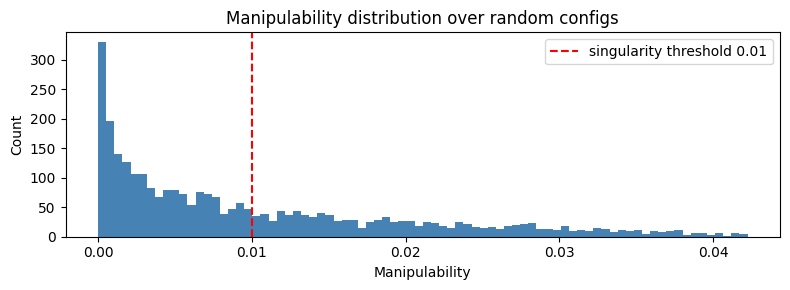

In [36]:

from ik.kinematics.fk import _Slist_np,_M_HOME_np,JOINT_LIMITS
N_SAMPLES = 3000
np.random.seed(42)

q_samples = np.random.uniform(
    JOINT_LIMITS[:, 0], JOINT_LIMITS[:, 1], size=(N_SAMPLES, 6)
)
manip_vals = np.array([manipulability(_Slist_np,q) for q in q_samples])

print(f"min:    {manip_vals.min():.4f}")
print(f"median: {np.median(manip_vals):.4f}")
print(f"max:    {manip_vals.max():.4f}")
print(f"near-singular (< 0.01): {(manip_vals < 0.01).sum()} / {N_SAMPLES}")

plt.figure(figsize=(8, 3))
plt.hist(manip_vals, bins=80, color="steelblue", edgecolor="none")
plt.axvline(0.01, color="red", linestyle="--", label="singularity threshold 0.01")
plt.xlabel("Manipulability")
plt.ylabel("Count")
plt.title("Manipulability distribution over random configs")
plt.legend()
plt.tight_layout()
plt.show()

## Wrist singularity trajectory

Joints 4 and 6 both rotate about the x-axis. When **joint 5 (wrist angle, index 4) → 0** they become collinear → wrist singularity.  
We build a trajectory where q[4] sweeps from +0.6 → 0 → -0.6 rad while all other joints are fixed.

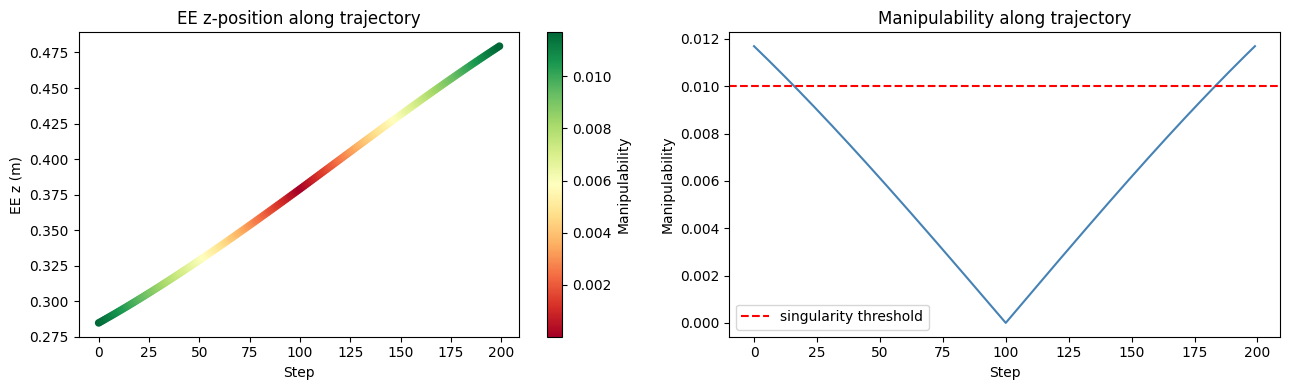

Min manipulability on trajectory: 0.00000 at step 100


In [78]:
# Ground-truth joint configs along trajectory (what we want the robot to follow)
q_A = np.array([0.3, -0.4, 0.5, 0.2,  0.6, 0.3])   # wrist angle = +0.6 (away)
q_B = np.array([0.3, -0.4, 0.5, 0.2,  0.0, 0.3])   # wrist angle =  0.0 (singularity)
q_C = np.array([0.3, -0.4, 0.5, 0.2, -0.6, 0.3])   # wrist angle = -0.6 (away)

# Interpolate A→B→C in joint space to get ground-truth poses
t_AB   = np.linspace(0, 1, N_TRAJ // 2, endpoint=False)
t_BC   = np.linspace(0, 1, N_TRAJ // 2)
q_traj = np.vstack([
    q_A + t[:, None] * (q_B - q_A) for t in [t_AB]
] + [
    q_B + t[:, None] * (q_C - q_B) for t in [t_BC]
])  # (N_TRAJ, 6)

T_traj  = np.array([FK(q) for q in q_traj])           # (N_TRAJ, 4, 4) — target poses
m_traj  = np.array([manipulability(_Slist_np,q) for q in q_traj])

# Plot EE path and manipulability along it
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
pos = T_traj[:, :3, 3]
sc  = ax.scatter(np.arange(N_TRAJ), pos[:, 2], c=m_traj, cmap="RdYlGn", s=20)
ax.set_xlabel("Step"); ax.set_ylabel("EE z (m)")
ax.set_title("EE z-position along trajectory")
plt.colorbar(sc, ax=ax, label="Manipulability")

ax = axes[1]
ax.plot(m_traj, color="steelblue")
ax.axhline(0.01, color="red", linestyle="--", label="singularity threshold")
ax.set_xlabel("Step"); ax.set_ylabel("Manipulability")
ax.set_title("Manipulability along trajectory")
ax.legend()

plt.tight_layout()
plt.show()
print(f"Min manipulability on trajectory: {m_traj.min():.5f} at step {m_traj.argmin()}")

In [16]:
!pip install modern-robotics
import numpy as np
import modern_robotics as mr
def IKinSpace_with_iters(Slist, M, T, thetalist0, eomg, ev):
    thetalist = np.array(thetalist0).copy()
    i = 0
    maxiterations = 50
    Tsb = mr.FKinSpace(M,Slist, thetalist)
    Vs = np.dot(mr.Adjoint(Tsb),mr.se3ToVec(mr.MatrixLog6(np.dot(mr.TransInv(Tsb), T))))
    err = np.linalg.norm([Vs[0], Vs[1], Vs[2]]) > eomg or np.linalg.norm([Vs[3], Vs[4], Vs[5]]) >  ev
    while err and i < maxiterations:
        thetalist = thetalist + np.dot(np.linalg.pinv(mr.JacobianSpace(Slist,thetalist)), Vs)
        i = i + 1
        Tsb = mr.FKinSpace(M, Slist, thetalist)
        Vs = np.dot(mr.Adjoint(Tsb), \
                    mr.se3ToVec(mr.MatrixLog6(np.dot(mr.TransInv(Tsb), T))))
        err = np.linalg.norm([Vs[0], Vs[1], Vs[2]]) > eomg \
              or np.linalg.norm([Vs[3], Vs[4], Vs[5]]) > ev
    return (thetalist, not err,i)

## Run comparison — NR cold start vs NR MLP warm start

In [100]:
cold_iters, cold_conv, cold_pos_err = [], [], []
warm_iters, warm_conv, warm_pos_err = [], [], []

#q_cold = q_traj[0].copy()   # both start at the true first config
#q_warm = q_traj[0].copy()
q_cold = q_traj[0].copy()   # both start at the true first config
q_warm = q_traj[0].copy()
for i, T_target in enumerate(T_traj):
    q_cold = np.array([0,0,0,0,0,0])   # both start at the true first config
    q_warm = np.array([0,0,0,0,0,0] )
    # --- cold start: NR initialised from previous solution ---
    q_sol_cold, conv_cold,it_cold = IKinSpace_with_iters(_Slist_np,_M_HOME_np,T_target,q_cold,0.001,0.001)
    err_cold = np.linalg.norm(T_target[:3, 3] - FK(q_sol_cold)[:3, 3])

    # --- warm start: MLP prediction → NR ---
    q_mlp = mlp_predict(q_warm, T_target, model, MinMax_X, MinMax_Y, DEVICE)
    q_sol_warm, conv_warm,it_warm = IKinSpace_with_iters(_Slist_np,_M_HOME_np, T_target,q_mlp,0.001,0.001)
    err_warm = np.linalg.norm(T_target[:3, 3] - FK(q_sol_warm)[:3, 3])

    cold_iters.append(it_cold);   cold_conv.append(conv_cold);  cold_pos_err.append(err_cold)
    warm_iters.append(it_warm);   warm_conv.append(conv_warm);  warm_pos_err.append(err_warm)

    # chain: next step initialises from this step's solution
    q_cold = q_sol_cold
    q_warm = q_sol_warm   # warm: chain from NR solution (MLP is the init, not the chain)

cold_iters  = np.array(cold_iters);  cold_pos_err = np.array(cold_pos_err)
warm_iters  = np.array(warm_iters);  warm_pos_err = np.array(warm_pos_err)

print(f"{'':25s} {'cold':>10} {'warm':>10}")
print(f"{'mean iterations':25s} {cold_iters.mean():>10.2f} {warm_iters.mean():>10.2f}")
print(f"{'converged (%)':25s} {100*np.mean(cold_conv):>10.1f} {100*np.mean(warm_conv):>10.1f}")
print(f"{'mean pos error (m)':25s} {np.median(cold_pos_err):>10.4f} {warm_pos_err.mean():>10.4f}")
print(f"{'max pos error (m)':25s} {cold_pos_err.max():>10.4f} {warm_pos_err.max():>10.4f}")

                                cold       warm
mean iterations                13.49       9.49
converged (%)                   97.0       99.0
mean pos error (m)            0.0000     0.0034
max pos error (m)             1.0900     0.3471


In [91]:
T_traj=FK_batch_full(torch.tensor(q_samples[:200],dtype=torch.float))
T_traj=T_traj.detach().cpu().numpy()

In [97]:
(cold_pos_err)

np.float64(4.0929746261257224e-05)

In [87]:
FK(q_warm)

array([[-0.14115088, -0.86155104,  0.48765381,  0.0460866 ],
       [-0.63242352,  0.45744566,  0.62512716, -0.18337771],
       [-0.76165407, -0.22016649, -0.60943399, -0.29804108],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [88]:
FK(q_cold)

array([[-0.1411518 , -0.86155439,  0.48764761,  0.04608653],
       [-0.63242347,  0.45744171,  0.6251301 , -0.18337794],
       [-0.76165394, -0.22016156, -0.60943594, -0.29804098],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

In [86]:
T_traj

array([[[-0.141149  , -0.8615532 ,  0.48765045,  0.046087  ],
        [-0.6324227 ,  0.45744246,  0.6251303 , -0.18337774],
        [-0.7616551 , -0.22016478, -0.6094333 , -0.29804122],
        [ 0.        ,  0.        ,  0.        ,  1.        ]]],
      dtype=float32)

## Visualise results

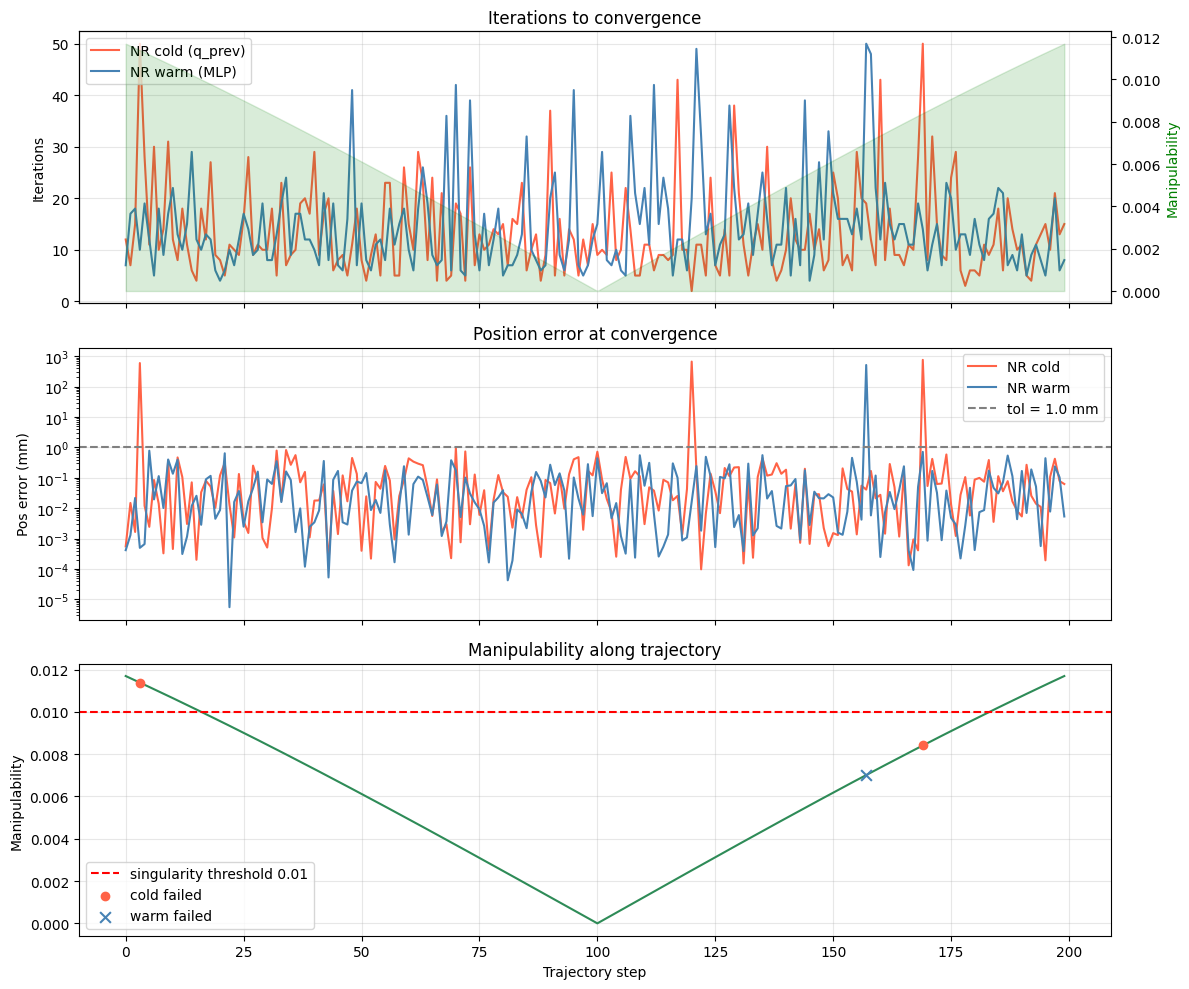

In [79]:
steps = np.arange(N_TRAJ)
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# — iterations to convergence —
ax = axes[0]
ax.plot(steps, cold_iters, label="NR cold (q_prev)", color="tomato",    linewidth=1.5)
ax.plot(steps, warm_iters, label="NR warm (MLP)",    color="steelblue", linewidth=1.5)
ax2 = ax.twinx()
ax2.fill_between(steps, m_traj, alpha=0.15, color="green", label="manipulability")
ax2.set_ylabel("Manipulability", color="green")
ax.set_ylabel("Iterations"); ax.set_title("Iterations to convergence")
ax.legend(loc="upper left"); ax.grid(True, alpha=0.3)

# — position error at convergence —
ax = axes[1]
ax.semilogy(steps, cold_pos_err * 1000, label="NR cold", color="tomato",    linewidth=1.5)
ax.semilogy(steps, warm_pos_err * 1000, label="NR warm", color="steelblue", linewidth=1.5)
ax.axhline(NR_TOL * 1000, color="gray", linestyle="--", label=f"tol = {NR_TOL*1000:.1f} mm")
ax.set_ylabel("Pos error (mm)"); ax.set_title("Position error at convergence")
ax.legend(); ax.grid(True, alpha=0.3)

# — manipulability along trajectory —
ax = axes[2]
ax.plot(steps, m_traj, color="seagreen", linewidth=1.5)
ax.axhline(0.01, color="red", linestyle="--", label="singularity threshold 0.01")
singular_steps = np.where(~np.array(cold_conv))[0]
warm_fail_steps = np.where(~np.array(warm_conv))[0]
if len(singular_steps):
    ax.scatter(singular_steps, m_traj[singular_steps], color="tomato",    zorder=5, label="cold failed")
if len(warm_fail_steps):
    ax.scatter(warm_fail_steps, m_traj[warm_fail_steps], color="steelblue", zorder=5, label="warm failed", marker="x", s=60)
ax.set_xlabel("Trajectory step"); ax.set_ylabel("Manipulability")
ax.set_title("Manipulability along trajectory"); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()